# Bootstrap

Статья: https://github.com/avito-tech/applied_statistics/blob/main/Bootstrap.ipynb

Бутстрап — способ построения доверительного интервала для любой характеристики распределения, состоящий из 2 эвристик:

- Замены истинного распределения на эмпирическое
- Генерация итоговой выборки с помощью Монте-Карло, чтобы корректно оценить квантили распределения

**Идея:** Мы предполагаем, что распределение ошибки в реальности $\Delta = (\hat{\theta} - \theta)$ такое же, как в бутстрап-мире $\Delta^* = (\hat{\theta}^* - \hat{\theta})$

Строим доверительный интервал 

$$
\Delta_{[alpha/2]} < \hat{\theta} - \theta < \Delta_{[1 - alpha/2]} \\
CI = (\hat{\theta} - \Delta_{[1 - alpha/2]}, \hat{\theta} - \Delta_{[alpha/2]})
$$

Заменяем $\Delta$ на $\Delta^*$

$$
CI = (\hat{\theta} - \Delta_{[1 - alpha/2]}^*, \hat{\theta} - \Delta_{[alpha/2]}^*) \\ 
CI = (2\hat{\theta} - \theta_{[1 - alpha/2]}^*, 2\hat{\theta} - \theta_{[alpha/2]}^*)
$$

**Когда Bootstrap работает?** 

- $N$ достаточно большое. Тогда эмпирическое распределение лучше приближается к истинному и мы точнее оцениваем $\Delta^*$
- $B$ достаточно большое ($\approx 10000$). Так мы точнее построим квантили распределения $\Delta^*$

> Eсли вы видите, что бутстрап дает доверительный интервал уже, чем t-test, то этим данным нельзя верить! Очень вероятно, что у бутстрапа в этот момент FPR больше, чем заявлен!

**Сравнение t-test с bootstrap:**

- bootstrap нельзя использовать, когда не работает t-test. Его FPR будет больше, чем у t-test в этом случае
- bootstrap не выигрывает по мощности у t-test. Они дают идентичные дов. интервалы, когда корректно работают.
- bootstrap работает в тысячи раз дольше, чем t-test.

**Рекомендации к использованию Bootstrap:**

- Применять на больших выборках. Если выборки маленькие, то по Монте Карло оценить корректность критерия
- Если можно использовать ttest, то использовать его


In [1]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from statsmodels.stats.power import tt_solve_power

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple, defaultdict

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

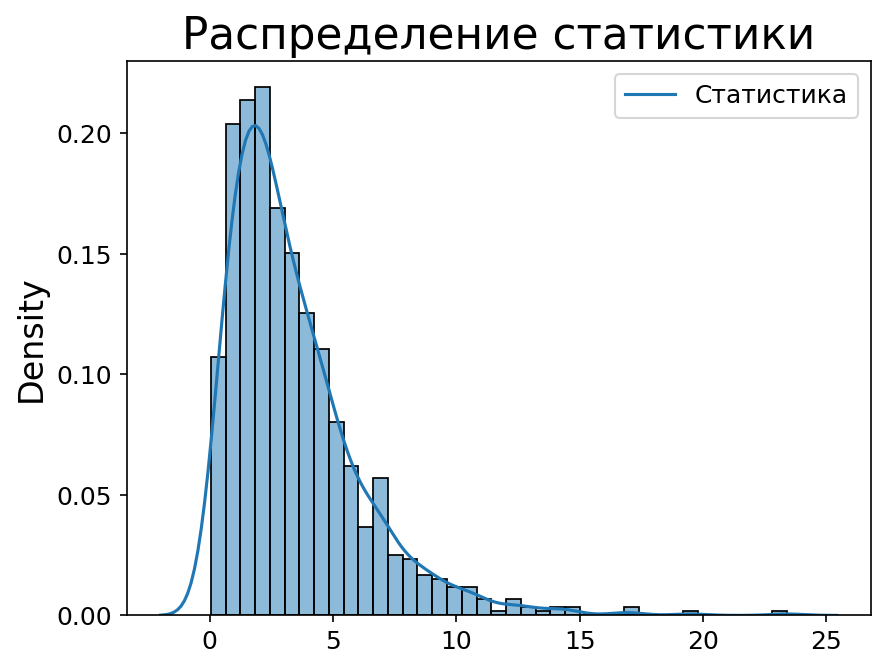

In [2]:
# Загружаем данные

sample = np.load("Bootstrap example 1.npy")

sns.histplot(sample, alpha=0.5, stat='density')
sns.kdeplot(sample, label='Статистика')
x = np.linspace(0, sample.max(), 1000)
plt.title(f"Распределение статистики")
plt.legend()
plt.show()

In [10]:
# Делаем Bootstrap, чтобы найти распределение 75% квантили

def get_statistic_bootstrap(sample, n_iter=1000):
    bootstrap = np.random.choice(sample, (n_iter, len(sample)), replace=True)

    quantiles = np.quantile(bootstrap, 0.75, axis=1)

    return quantiles

statistics = get_statistic_bootstrap(sample)

alpha = 0.05

ci_left, ci_right = np.quantile(statistics, [alpha / 2, 1 - alpha / 2])

print(f"Sampled 75% Quantile: {np.quantile(sample, 0.75):.1f}, CI = [{ci_left:.1f}, {ci_right:.1f}]")

Sampled 75% Quantile: 8.1, CI = [8.0, 8.3]


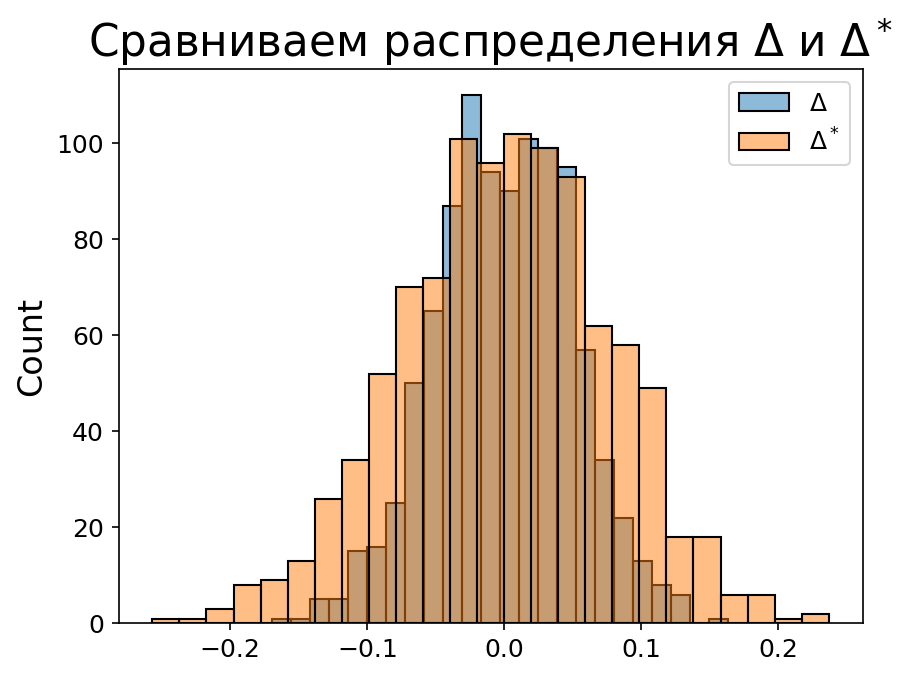

In [10]:
# Проверяем, что delta = y_est - y_true распределено примерно, как delta* = y_hat - y_est

n_iter = 1000

sample_size = 20000
y_true = stats.gamma(a=2, scale=3).ppf(0.75)
sample_example = stats.gamma(a=2, scale=3).rvs((n_iter,  sample_size))
y_est = np.quantile(sample_example, 0.75, axis=1)

# Bootstrap, чтобы найти y_hat
y_hat = get_statistic_bootstrap(sample_example[0,:])

delta1 = y_est - y_true
delta2 = y_hat - y_est

sns.histplot(delta1, alpha=0.5, label='$\\Delta$')
sns.histplot(delta2, alpha=0.5, label="$\\Delta^*$")
plt.title("Сравниваем распределения $\\Delta$ и $\\Delta^*$")
plt.legend()

In [ ]:
# Считаем доверительный интервал

def get_pivotal_ci(bootstrap_stats, estimated_value, alpha):
    ci_left, ci_right = 2 * estimated_value - np.quantile(bootstrap_stats, [1 - alpha / 2, alpha / 2])
    return ci_left, ci_right

ci_left, ci_right = get_pivotal_ci(y_hat, y_est[0], 0.05)

print(f"Estimated 0.75 percentile = {y_est[0]:.1f}, Pivotal CI = [{ci_left:.1f}, {ci_right:.1f}]")

Estimated 0.75 percentile = 8.1, Pivotal CI = [8.0, 8.2]


In [11]:
# Проверим гипотезу, что наше истинное theta равно некоторму числу

def get_pvalue(bootstrap_stats, theta_true):
    cdf_left = np.mean(bootstrap_stats < theta_true)
    cdf_right = 1 - cdf_left

    pvalue = 2 * min(cdf_left, cdf_right)

    return pvalue

alpha = 0.05
sample_size = 5000

true_distribution = stats.gamma(a=2, scale=3)
theta_true = true_distribution.ppf(0.75)

# A/A тест и A/B тест, ищем typeOne
count = 0
dict = defaultdict(list)
n_iter = 1000
for _ in tqdm(range(n_iter)):
    # При нулевой гипотезе выбока генерируется из true_distribution
    sample = true_distribution.rvs(sample_size)
    estimated_quantile = np.quantile(sample, 0.75)

    bootstrap_stats = get_statistic_bootstrap(sample, n_iter=2000)

    pvalue = get_pvalue(bootstrap_stats, theta_true)

    dict['A/A'].append(pvalue)

    ci_left, ci_right = get_pivotal_ci(bootstrap_stats, estimated_quantile, alpha)

    count += (0 if ci_left < theta_true < ci_right else 1)

    # Делаем A/B тест: берем другое распределение
    sample_ab = stats.gamma(a=3, scale=3).rvs(sample_size)
    estimated_quantile_ab = np.quantile(sample_ab, 0.75)

    bootstrap_stats_ab = get_statistic_bootstrap(sample_ab)

    pvalue_ab = get_pvalue(bootstrap_stats_ab, theta_true)
    
    dict['A/B'].append(pvalue_ab)


100%|██████████| 1000/1000 [03:29<00:00,  4.78it/s]


Type One = 0.069, CI = [0.055, 0.086]


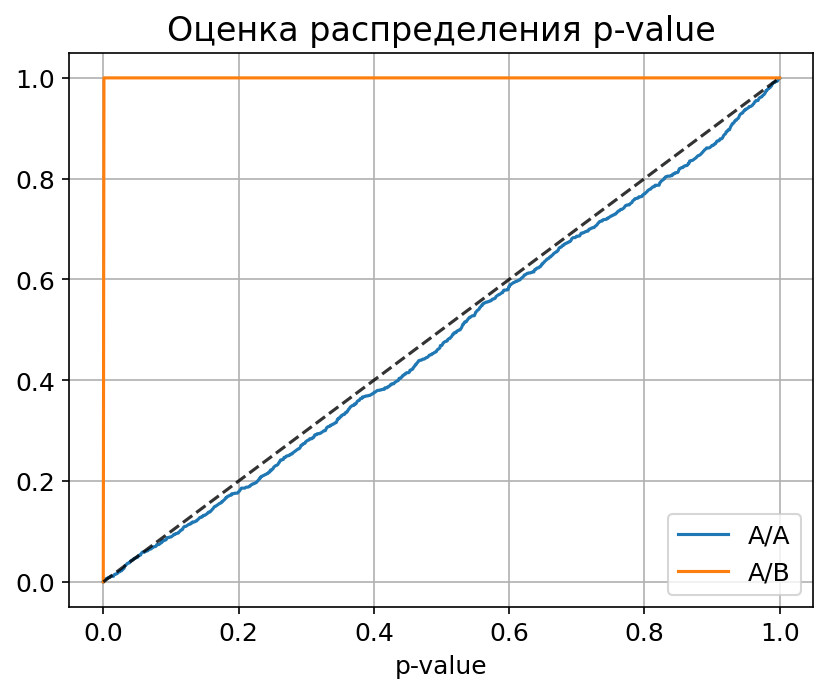

In [15]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        # Эмпирическая CDF для pvalue
        Y = [np.mean(np.array(pvalues) < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

typeOne = count / n_iter

typeOneCiLeft, typeOneCiRight = proportion_confint(count=count, nobs=n_iter, alpha=0.05, method='wilson')

print(f"Type One = {typeOne:.3f}, CI = [{typeOneCiLeft:.3f}, {typeOneCiRight:.3f}]")

plot_pvalue_distribution(dict)

In [36]:
# USEFUL METHODS

monteCarloResults = namedtuple('MonteCarloResults', ['type_one', 'ci_left', 'ci_right'])

# Calculte the statistic distribution using Bootstrap
def get_statistic_bootstrap_new(sample, func, n_iter=1000):
    bootstrap = np.random.choice(sample, (n_iter, len(sample)), replace=True)

    quantiles = func(bootstrap)

    return quantiles

# Different ways to get CI
def get_normal_ci(bootstrap_stats, estimated_value, alpha):
    t = stats.norm().ppf(1 - alpha / 2)

    se = np.sqrt(bootstrap_stats.var())

    ci_left = estimated_value - t * se
    ci_right = estimated_value + t * se

    return (ci_left, ci_right)

def get_percentile_ci(bootstrap_stats, estimated_value, alpha):
    ci_left, ci_right = np.quantile(bootstrap_stats, [alpha / 2, 1 - alpha / 2])
    return ci_left, ci_right

def get_pivotal_ci(bootstrap_stats, estimated_value, alpha):
    ci_left, ci_right = 2 * estimated_value - np.quantile(bootstrap_stats, [1 - alpha / 2, alpha / 2])
    return ci_left, ci_right

# Get a pvalue from bootstrap_stats
def get_pvalue(bootstrap_stats, theta_estimated):
    cdf_left = np.mean(bootstrap_stats < theta_estimated)
    cdf_right = 1 - cdf_left

    pvalue = 2 * min(cdf_left, cdf_right)

    return pvalue

# Does a Monte Carlo to estimate typeOne using a CI method
def run_monte_carlo_aa_ci(sample_size, true_distribution, theta_true, theta_func, ci_func, alpha, name, isAB, mk_dict):

    typeOne = 0

    pvalues_dict = defaultdict(list)

    n_iter = 1000
    for _ in tqdm(range(n_iter)):
        # Get a sample and calculate the estimate
        sample = true_distribution.rvs(sample_size)
        estimated_value = float(theta_func(sample[None, :])[0]) # add a dimension

        # Find the estimate distribution using Bootstrap
        bootstrap_stats = get_statistic_bootstrap_new(sample=sample, func=theta_func, n_iter=1000)

        pvalue = get_pvalue(bootstrap_stats, theta_true)

        pvalues_dict["A/B" if isAB else "A/A"].append(pvalue)

        ci_left, ci_right= ci_func(bootstrap_stats, estimated_value, alpha)

        # Check our criteria
        typeOne += (0 if ci_left < theta_true < ci_right else 1)
    
    # Normal CI results
    type_one = typeOne / n_iter
    ci_left, ci_right = proportion_confint(count=typeOne, nobs=n_iter, alpha=0.05, method='wilson')

    mk_normal = monteCarloResults(**{'type_one' : type_one, 'ci_left': ci_left, 'ci_right': ci_right})

    mk_dict[name].append([sample_size, mk_normal, pvalues_dict])

# Monte Carlo for ttest
def run_monte_carlo_aa_ttest(sample_size, true_distribution, theta_true, alpha, name, isAB, mk_dict):

    typeOne = 0

    pvalues_dict = defaultdict(list)

    n_iter = 1000
    for _ in range(n_iter):
        # Get a sample and calculate the estimate
        sample = true_distribution.rvs(sample_size)

        pvalue = stats.ttest_1samp(sample, popmean=theta_true).pvalue

        pvalues_dict["A/B" if isAB else "A/A"].append(pvalue)

        typeOne += (1 if pvalue < alpha else 0)
    
    # Normal CI results
    type_one = typeOne / n_iter
    ci_left, ci_right = proportion_confint(count=typeOne, nobs=n_iter, alpha=0.05, method='wilson')

    mk = monteCarloResults(**{'type_one' : type_one, 'ci_left': ci_left, 'ci_right': ci_right})

    mk_dict[name].append([sample_size, mk, pvalues_dict])


In [ ]:
# Оцениваем 50% квантиль экспоненциального распределения и смотрим на typeOne 
# для разных типов получения CI для Bootstrap

mk_dict = defaultdict(list) # Store Monte Carlo Results

N_to_check = [50, 100, 500, 1000, 3000] # Different sample sizes

alpha = 0.05

true_distribution = stats.expon(scale=5)
theta_true = true_distribution.ppf(0.5)

for sample_size in tqdm(N_to_check):
    # Normal CI
    run_monte_carlo_aa_ci(sample_size,
                          true_distribution, 
                          theta_true, # Our actual parameter
                          lambda x: np.quantile(x, 0.5, axis=1),  # Function to estimate a parameter from a sample
                          get_normal_ci,  # What function to use to get a CI
                          alpha,
                          "Normal CI",  # Name of current method
                          False, # flag for AB test
                          mk_dict) # mk_dict["Normal CI"] will have the Monte Carlo Results

    # Percentile CI
    run_monte_carlo_aa_ci(sample_size,
                          true_distribution, 
                          theta_true,
                          lambda x: np.quantile(x, 0.5, axis=1),
                          get_percentile_ci,
                          alpha,
                          "Percentile CI",
                          False,
                          mk_dict)
    
    # Pivotal CI
    run_monte_carlo_aa_ci(sample_size,
                          true_distribution, 
                          theta_true,
                          lambda x: np.quantile(x, 0.5, axis=1),
                          get_pivotal_ci,
                          alpha,
                          "Pivotal CI",
                          False,
                          mk_dict)

(0.0, 0.19369579109412358)

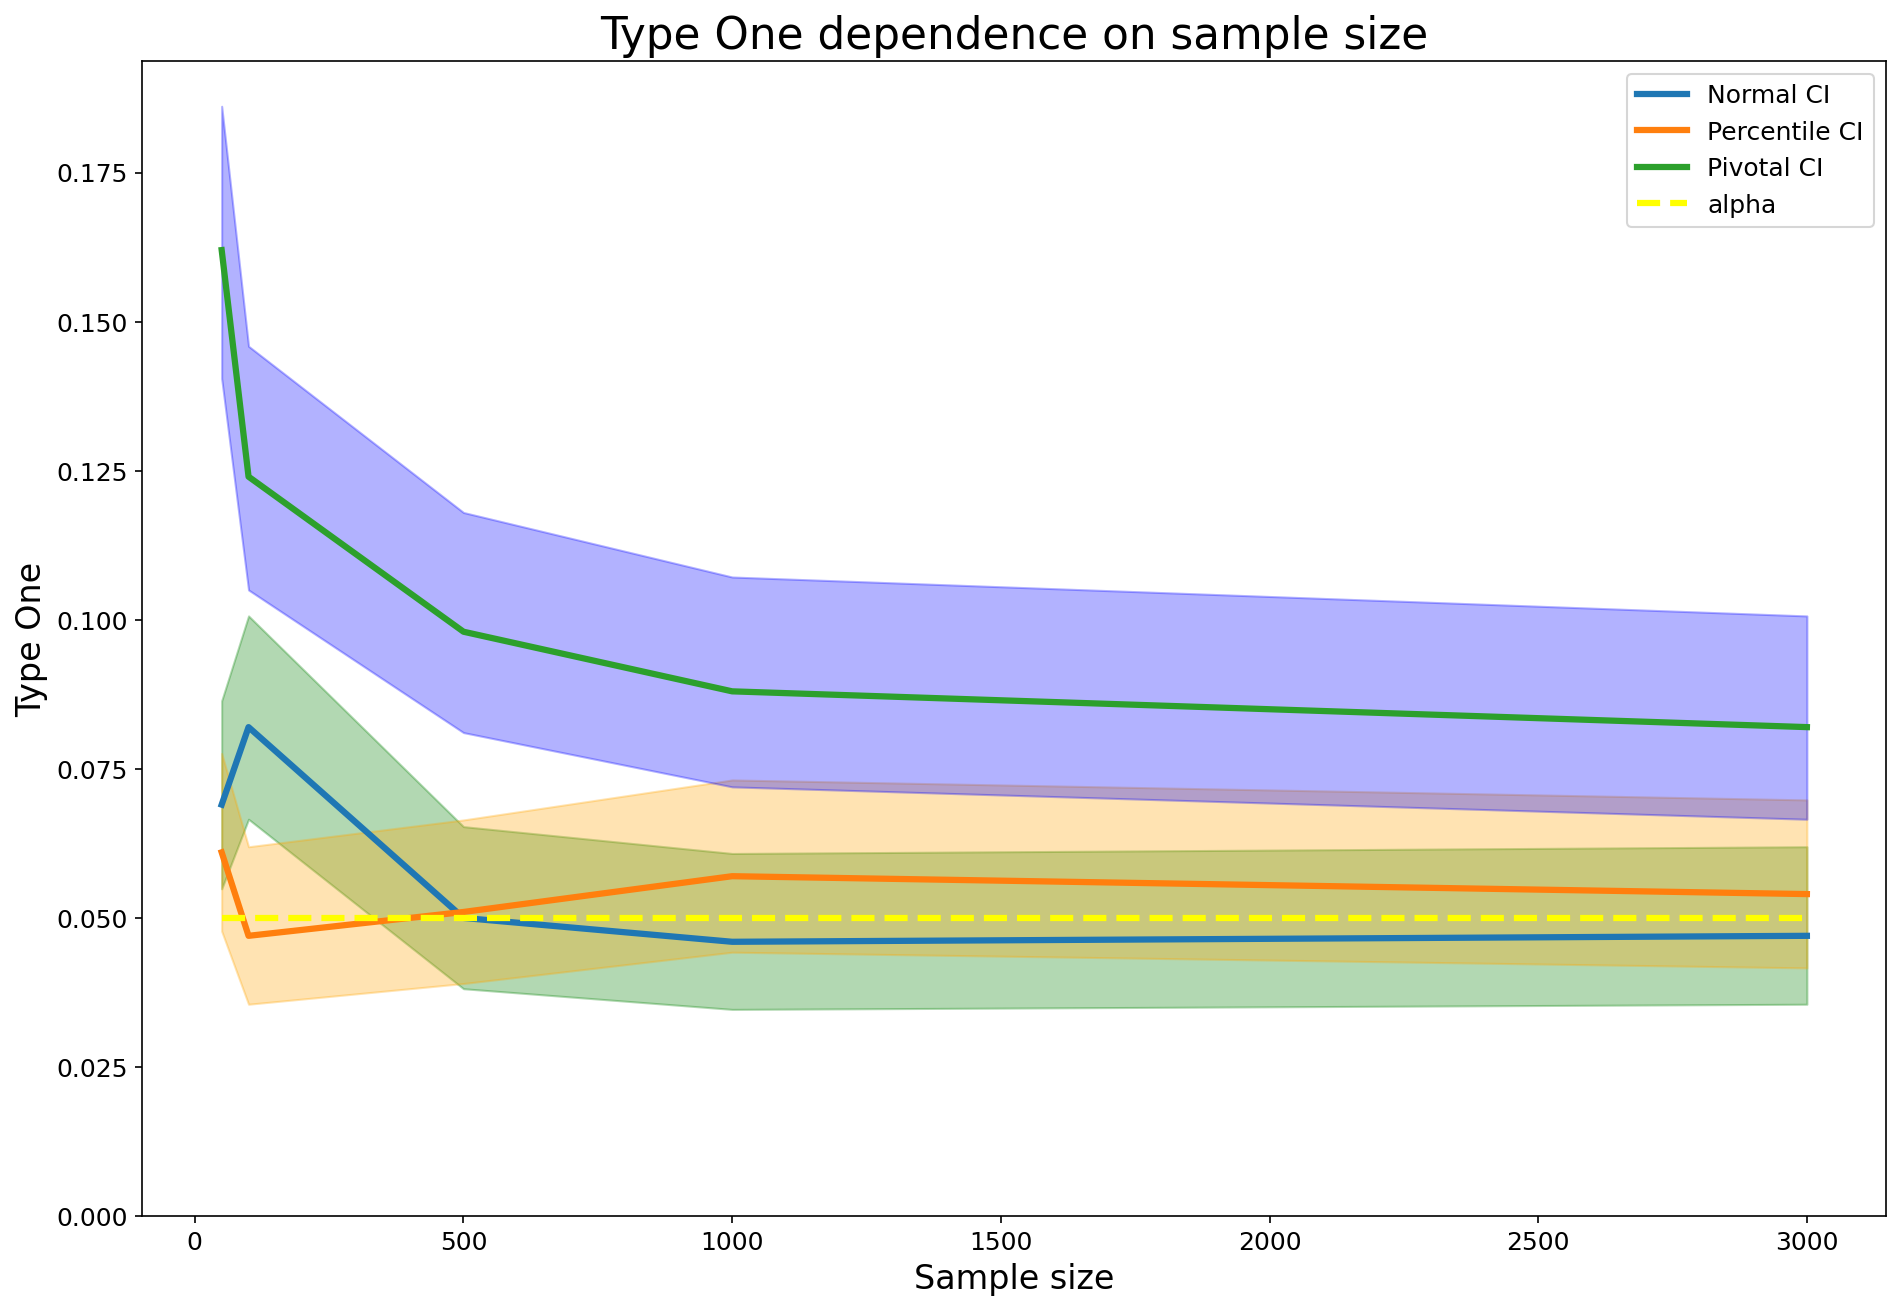

In [42]:
# Рисуем Type One для разных N

plt.figure(figsize=(15, 10))

plt.plot([elem[0] for elem in mk_dict['Normal CI']], 
            [elem[1].type_one for elem in mk_dict['Normal CI']], linewidth=3.0, label='Normal CI')
plt.fill_between([elem[0] for elem in mk_dict['Normal CI']], 
                    [elem[1].ci_left for elem in mk_dict['Normal CI']], 
                    [elem[1].ci_right for elem in mk_dict['Normal CI']], 
                    color = 'green', alpha = 0.3)

plt.plot([elem[0] for elem in mk_dict['Percentile CI']], 
            [elem[1].type_one for elem in mk_dict['Percentile CI']], linewidth=3.0, label='Percentile CI')
plt.fill_between([elem[0] for elem in mk_dict['Percentile CI']], 
                    [elem[1].ci_left for elem in mk_dict['Percentile CI']], 
                    [elem[1].ci_right for elem in mk_dict['Percentile CI']], 
                    color = 'orange', alpha = 0.3)

plt.plot([elem[0] for elem in mk_dict['Pivotal CI']], 
            [elem[1].type_one for elem in mk_dict['Pivotal CI']], linewidth=3.0, label='Pivotal CI')
plt.fill_between([elem[0] for elem in mk_dict['Pivotal CI']], 
                    [elem[1].ci_left for elem in mk_dict['Pivotal CI']], 
                    [elem[1].ci_right for elem in mk_dict['Pivotal CI']], 
                    color = 'blue', alpha = 0.3)

plt.plot([elem[0] for elem in mk_dict['Normal CI']], np.array([0.05]*len(mk_dict['Normal CI'])),
            color = 'yellow', linestyle = 'dashed', 
            linewidth=3.0, label='alpha')

plt.legend()
plt.title("Type One dependence on sample size")
plt.xlabel("Sample size")
plt.ylabel("Type One")
plt.ylim(bottom=0)

In [ ]:
# Now let's estimate the mean and compare to ttest

mk_dict_new = defaultdict(list)

true_distribution = stats.expon(scale=5)
theta_true = true_distribution.mean()

for sample_size in tqdm(N_to_check):
    # Normal CI
    run_monte_carlo_aa_ci(sample_size,
                          true_distribution, 
                          theta_true, # Our actual parameter
                          lambda x: np.mean(x, axis=1),  # Function to estimate a parameter from a sample
                          get_normal_ci,  # What function to use to get a CI
                          alpha,
                          "Normal CI",  # Name of current method
                          False,
                          mk_dict_new) # mk_dict["Normal CI"] will have the Monte Carlo Results

    # Percentile CI
    run_monte_carlo_aa_ci(sample_size,
                          true_distribution, 
                          theta_true,
                          lambda x: np.mean(x, axis=1),
                          get_percentile_ci,
                          alpha,
                          "Percentile CI",
                          False,
                          mk_dict_new)
    
    # Pivotal CI
    run_monte_carlo_aa_ci(sample_size,
                          true_distribution, 
                          theta_true,
                          lambda x: np.mean(x, axis=1),
                          get_pivotal_ci,
                          alpha,
                          "Pivotal CI",
                          False,
                          mk_dict_new)
    
    # Ttest
    run_monte_carlo_aa_ttest(sample_size,
                          true_distribution, 
                          theta_true,
                          alpha,
                          "Ttest",
                          False,
                          mk_dict_new)

100%|██████████| 5/5 [00:54<00:00, 10.97s/it]


(0.0, 0.12002294412524271)

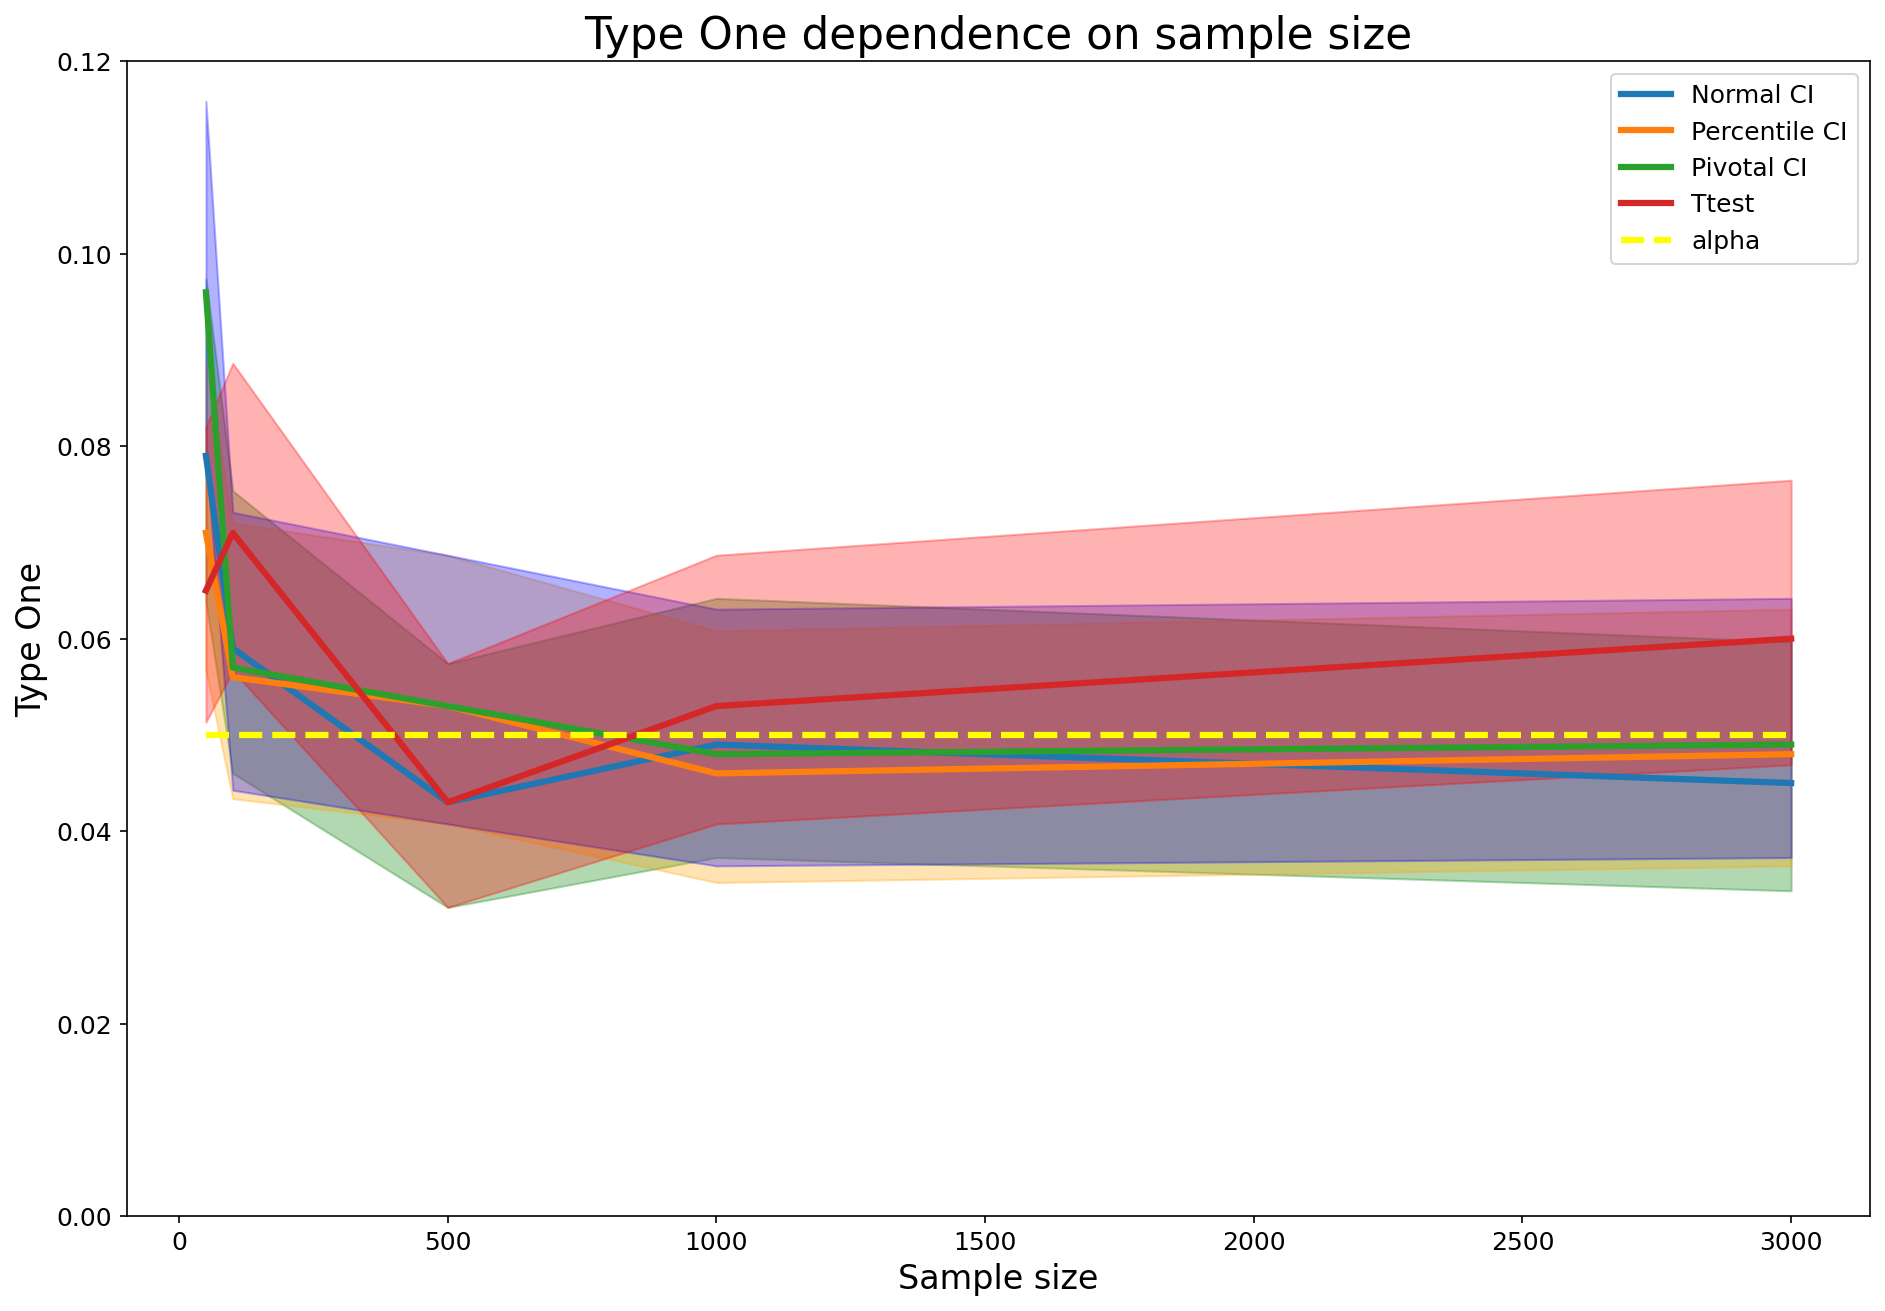

In [49]:
# Рисуем Type One для разных N

plt.figure(figsize=(15, 10))

plt.plot([elem[0] for elem in mk_dict_new['Normal CI']], 
            [elem[1].type_one for elem in mk_dict_new['Normal CI']], linewidth=3.0, label='Normal CI')
plt.fill_between([elem[0] for elem in mk_dict_new['Normal CI']], 
                    [elem[1].ci_left for elem in mk_dict_new['Normal CI']], 
                    [elem[1].ci_right for elem in mk_dict_new['Normal CI']], 
                    color = 'green', alpha = 0.3)

plt.plot([elem[0] for elem in mk_dict_new['Percentile CI']], 
            [elem[1].type_one for elem in mk_dict_new['Percentile CI']], linewidth=3.0, label='Percentile CI')
plt.fill_between([elem[0] for elem in mk_dict_new['Percentile CI']], 
                    [elem[1].ci_left for elem in mk_dict_new['Percentile CI']], 
                    [elem[1].ci_right for elem in mk_dict_new['Percentile CI']], 
                    color = 'orange', alpha = 0.3)

plt.plot([elem[0] for elem in mk_dict_new['Pivotal CI']], 
            [elem[1].type_one for elem in mk_dict_new['Pivotal CI']], linewidth=3.0, label='Pivotal CI')
plt.fill_between([elem[0] for elem in mk_dict_new['Pivotal CI']], 
                    [elem[1].ci_left for elem in mk_dict_new['Pivotal CI']], 
                    [elem[1].ci_right for elem in mk_dict_new['Pivotal CI']], 
                    color = 'blue', alpha = 0.3)

plt.plot([elem[0] for elem in mk_dict_new['Ttest']], 
            [elem[1].type_one for elem in mk_dict_new['Ttest']], linewidth=3.0, label='Ttest')
plt.fill_between([elem[0] for elem in mk_dict_new['Ttest']], 
                    [elem[1].ci_left for elem in mk_dict_new['Ttest']], 
                    [elem[1].ci_right for elem in mk_dict_new['Ttest']], 
                    color = 'red', alpha = 0.3)

plt.plot([elem[0] for elem in mk_dict_new['Normal CI']], np.array([0.05]*len(mk_dict_new['Normal CI'])),
            color = 'yellow', linestyle = 'dashed', 
            linewidth=3.0, label='alpha')

plt.legend()
plt.title("Type One dependence on sample size")
plt.xlabel("Sample size")
plt.ylabel("Type One")
plt.ylim(bottom=0)

In [41]:
# Now let's do A/B test to compare powers of different methods

alpha = 0.05

mk_dict_newnew = defaultdict(list)
# It will store {"Normal CI": [[sample_size1, mk_res, pvalues_dict], ...]}

true_distribution = stats.expon(scale=5)
theta_true = true_distribution.mean()

sample_size = 1000

# Normal CI A/A
run_monte_carlo_aa_ci(sample_size,
                        true_distribution,
                        theta_true, # Our actual parameter
                        lambda x: np.mean(x, axis=1),  # Function to estimate a parameter from a sample
                        get_normal_ci,  # What function to use to get a CI
                        alpha,
                        "Normal CI A/A",  # Name of current method
                        False, # isAB = False
                        mk_dict_newnew) # mk_dict["Normal CI"] will have the Monte Carlo Results

# Normal CI
run_monte_carlo_aa_ci(sample_size,
                        stats.expon(scale=6), # Changed the distribtion for A/B test
                        theta_true, # Our actual parameter
                        lambda x: np.mean(x, axis=1),  # Function to estimate a parameter from a sample
                        get_normal_ci,  # What function to use to get a CI
                        alpha,
                        "Normal CI",  # Name of current method
                        True,
                        mk_dict_newnew) # mk_dict["Normal CI"] will have the Monte Carlo Results

# Percentile CI
run_monte_carlo_aa_ci(sample_size,
                        stats.expon(scale=6), 
                        theta_true,
                        lambda x: np.mean(x, axis=1),
                        get_percentile_ci,
                        alpha,
                        "Percentile CI",
                        True,
                        mk_dict_newnew)
    
# Pivotal CI
run_monte_carlo_aa_ci(sample_size,
                        stats.expon(scale=6), 
                        theta_true,
                        lambda x: np.mean(x, axis=1),
                        get_pivotal_ci,
                        alpha,
                        "Pivotal CI",
                        True,
                        mk_dict_newnew)
    
# Ttest
run_monte_carlo_aa_ttest(sample_size,
                        stats.expon(scale=6), 
                        theta_true,
                        alpha,
                        "Ttest",
                        True,
                        mk_dict_newnew)

dict_to_plot = {
    "Normal CI A/A": mk_dict_newnew["Normal CI A/A"][0][-1]["A/A"],
    "Normal CI A/B": mk_dict_newnew["Normal CI"][0][-1]["A/B"],
    "Percentile CI A/B": mk_dict_newnew["Percentile CI"][0][-1]["A/B"],
    "Pivotal CI A/B": mk_dict_newnew["Pivotal CI"][0][-1]["A/B"],
    "Ttest A/B": mk_dict_newnew["Ttest"][0][-1]["A/B"]
}

100%|██████████| 1000/1000 [00:01<00:00, 553.41it/s]


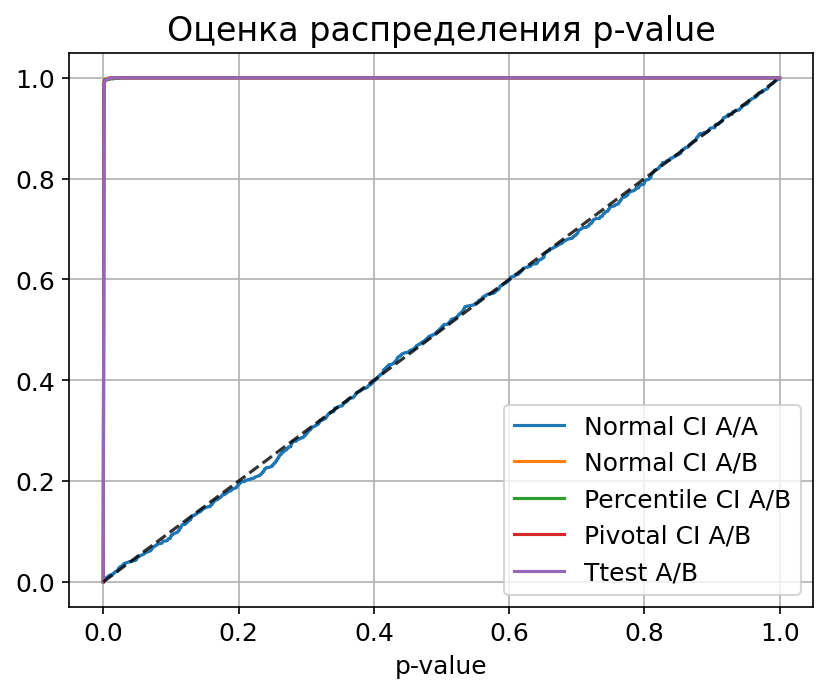

In [42]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        # Эмпирическая CDF для pvalue
        Y = [np.mean(np.array(pvalues) < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

plot_pvalue_distribution(dict_to_plot)

In [43]:
print(f"Normal CI: ({mk_dict_newnew["Normal CI"][0][1].ci_left:.3f}, {mk_dict_newnew["Normal CI"][0][1].ci_right:.3f}). Length = {(mk_dict_newnew["Normal CI"][0][1].ci_right - mk_dict_newnew["Normal CI"][0][1].ci_left):.3f}")
print(f"Percentile CI: ({mk_dict_newnew["Percentile CI"][0][1].ci_left:.3f}, {mk_dict_newnew["Percentile CI"][0][1].ci_right:.3f}). Length = {(mk_dict_newnew["Percentile CI"][0][1].ci_right - mk_dict_newnew["Percentile CI"][0][1].ci_left):.3f}")
print(f"Pivotal CI: ({mk_dict_newnew["Pivotal CI"][0][1].ci_left:.3f}, {mk_dict_newnew["Pivotal CI"][0][1].ci_right:.3f}). Length = {(mk_dict_newnew["Pivotal CI"][0][1].ci_right - mk_dict_newnew["Pivotal CI"][0][1].ci_left):.3f}")

Normal CI: (0.996, 1.000). Length = 0.004
Percentile CI: (0.996, 1.000). Length = 0.004
Pivotal CI: (0.996, 1.000). Length = 0.004
